# ベイズ線形回帰による異常検知

7章で解説した最尤推定と並び、統計モデルの学習（パラメータ推定）によく用いられる手法として**ベイズ推定**（Bayesian inference）が挙げられます。

ベイズ推定を用いることで、最尤推定と比べて以下のような**メリット**が得られます。

- データが少ない場合でも、パラメータ推定の不確実性を考慮できる
- 事前分布を通じてドメイン知識をモデルに反映できる
- 複雑なモデルを柔軟に構築できる

一方でベイズ推定は最尤推定と比べて、以下のような**デメリット**を被る可能性があります。

- モデリングの工数が増える
- モデリングの難易度が上がる
- 学習・推論速度が遅くなる

ベイズ推定と最尤推定の使い分けについては、書籍中の内容も参考にしながら選択を行なってください。一般的には階層モデルのような複雑なモデルの構築や、学習データが少ないケースにベイズ推定が向いています。

ベイズ推定をパラメータ推定に用いた統計モデリング手法を、**ベイズ統計モデリング**（Bayesian statistical modeling）と呼びます。ベイズ統計モデリングは解析的な計算が難しいことから、いくつかの近似計算手法が提案されており、その中でも代表的な手法である**MCMC**（Markov chain Monte Carlo methods：マルコフ連鎖モンテカルロ法）は、計算アルゴリズムやライブラリの進歩から近年急速に普及が進んでいます。

ここではシンプルなケースとして、線形回帰モデルにベイズ推定を用いた、**ベイズ線形回帰モデル**（Bayesian linear regression）を紹介します。
このベイズ線形回帰モデルによる異常検知を、Pythonを用いて以下の手順で実装する方法を解説します。

- A. 変数の選択
- B. モデルの学習
- C. 推論

なおデータセットには7.2節で作成したサンプルデータを使用し、入力する変数は`year`（経過年数）、`odometer`（総走行距離）、`model_name`（車種。この変数のみカテゴリ変数）の3変数を、ターゲットとする誤報率としては0.0027を採用します（最尤推定による多変数線形回帰モデルと同様）。

## A. 変数の選択

最尤推定による多変数線形回帰モデル（[ch7_4_Multivariate_Linear_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch7_4_Multivariate_Linear_Regression.ipynb)）と同様のため、省略します。

## B. モデルの学習

MCMCを用いたベイズ統計モデリングをPythonで行うには、PyStanやNumPyro、Tensorflow Probability等の**確率的プログラミング言語**（probabilistic programming language）を用います。本書ではこの確率的プログラミングの一種である[PyMC](https://www.pymc.io/welcome.html)を用いてベイズ統計モデリングを実装します。

MCMCを用いたモデリング（異常検知における学習に相当）は、最尤推定と比べて収束確認のように人が介在すべき操作が増える傾向にあります。流れをわかりやすくするために、以下の4ステップに分けて実装法を解説します。

- I. MCMCの実行
- II. 収束の確認
- III. 学習データからしきい値を計算
- IV. MCMC サンプルを保存

### I. MCMCの実行

PyMCでは、`pm.Model`クラスのインスタンスを作成したのち、`with`構文のインデント内で事前分布、線形予測子、リンク関数、確率分布などのモデルの定義を記述します。

今回の多変数線形回帰モデルでは、$w_0,\boldsymbol{w},\sigma$の各パラメータに事前分布を設定する必要があります。このとき、ドメイン知識が乏しい場合を想定して無情報に近い事前分布を用います。
具体的には、パラメータ$w_0,\boldsymbol{w}$の事前分布として`sigma=100`の分散が⼤きい正規分布を、$\sigma$の事前分布には正の範囲のみをとることを考慮して`sigma=100`の半正規分布（正規分布の正の範囲のみを切り出して規格化した確率分布）を指定します。

モデルの定義が完了したら、`with`構文のインデント内で`pm.sample`関数を実行することで、MCMC によるサンプリングを開始します。サンプリングが終わるまでしばらく待ちます。

In [ ]:
# コード8.1 MCMC によるベイズ線形回帰モデルのパラメータ推定
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import pymc as pm

###### 学習データの読み込みと前処理（7章の最尤推定による多変数線形回帰モデルと同様）######
# CSVからPandas DataFrameに学習データ読み込み
df = pd.read_csv('./datasets/usedcar_dataset_train.csv')
# 正常データのみを抽出
df_normal = df[df['label'] == 'normal']
# カテゴリ変数'model_name'の数値化（one-hot encoding）
enc = OneHotEncoder(drop='first')
model_name_cat = enc.fit_transform(df_normal[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_normal.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数と応答変数（'price'）を別々に保持（応答変数のみndarray化）
X_train = df_encoded[['year', 'odometer']+model_cat_names]
y_train = df_encoded['price'].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
X_train = X_train.to_numpy() # X_trainをndarray化
seed=42 # 乱数シードを指定（結果の再現性を担保）
# モデル定義用のインスタンスを作成
multi_regression_model = pm.Model()
with multi_regression_model:
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0 = pm.Normal("w_0", mu=0, sigma=100)
    w = pm.Normal("w", mu=0, sigma=100, shape=4)
    sigma = pm.HalfNormal("sigma", sigma=100)
    # 線形予測子
    mu = w_0 + w[0]*X_train[:, 0] + w[1]*X_train[:, 1] \
        + w[2]*X_train[:, 2] + w[3]*X_train[:, 3]
    # 確率分布
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_train)
    # MCMCの実行（学習）
    with multi_regression_model:
        trace = pm.sample(random_seed=seed)
    # 得られた事後分布のMCMCサンプルを表示
    trace.posterior

ステップI（MCMCの実行）はこれで完了ですが、このタイミングでPyMCによるMCMCの実装に役立つ知識を紹介しておきます。

PyMCによる実装では、以下に挙げるデータ型の使い分けに注意してください。

- 学習データの入力：Numpy のnumpy.ndarray 型
- モデルの定義：[PyTensor](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_pytensor.html)の`pytensor.tensor`型
- 学習後に取得できるMCMCサンプル：[xarray](https://docs.xarray.dev/en/stable/)の`xarray.DataArray`型

特に学習で生成されるMCMCサンプルは、`xarray.DataArray`型を構成要素とする`xarray.DataSet`型として得られるため、ここから事後分布を可視化したり予測分布を得るためには、xarrayの演算の仕組みを把握することが重要です。後ほど具体的な方法を解説します。

またPyMCで定義したモデル構造は、以下に示す`pm.model_to_graphviz`関数でグラフィカルモデルとして可視化できます。

In [ ]:
# コード8.2 PyMC のmodel_to_graphviz() 関数によるグラフィカルモデル可視化
pm.model_to_graphviz(multi_regression_model)

モデルの線形予測子の定義では、以下のように説明変数の係数w[j] がすべて記述されているため、説明変数の数が多い場合は実装が長くなってしまいます。

```python
# コード8.3 線形予測子の定義部分
mu = w_0 + w[0]*X_train[:, 0] + w[1]*X_train[:, 1] \
2 + w[2]*X_train[:, 2] + w[3]*X_train[:, 3]
```

このような線形予測子の定義は`pytensor.tensor`の行列積の演算`pt.dot`を利用して、以下のように短く書き換えることもできます。

```python
# コード8.4 線形予測子の定義（行列積で一括計算）
import pytensor.tensor as pt
mu = w_0 + pt.dot(X_train, w)
```

また、説明変数の定義を`pm.Data`クラスで、線形予測子の定義を`pm.Deterministic`クラス（決定論的に決まる変数を定義できる）で記述し、`dims`引数で添字に相当するインデックス名を指定すると、説明変数や添字を名前付きで管理でき、可視化やデバッグがしやすくなります。

> Note：紙面上では`pm.ConstantData`としていましたが、PyMCのバージョンによっては動作しないため、`pm.Data`に変更しています

In [ ]:
# コード8.5 PyMC におけるDeterministic クラスによるモデル式の詳細定義
multi_regression_model = pm.Model()

with multi_regression_model:
    # 説明変数
    x0 = pm.Data("x0", X_train[:, 0], dims="i")
    x1 = pm.Data("x1", X_train[:, 1], dims="i")
    x2 = pm.Data("x2", X_train[:, 2], dims="i")
    x3 = pm.Data("x3", X_train[:, 3], dims="i")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0 = pm.Normal("w_0", mu=0, sigma=100)
    w = pm.Normal("w", mu=0, sigma=100, shape=4, dims="j")
    sigma = pm.HalfNormal("sigma", sigma=100)
    # 線形予測子
    mu = pm.Deterministic("mu", w_0 + w[0] * x0 + w[1] * x1 \
                          + w[2] * x2 + w[3] * x3, dims="i")
    # 確率分布
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_train, dims="i")

このモデル式に基づき`pm.model_to_graphviz`関数でグラフィカルモデルを可視化すると、説明変数やインデックス名が追記されて出力されます。

In [ ]:
pm.model_to_graphviz(multi_regression_model)

モデルの構造⾃体は元の記述方法と同じなので、モデルをどこまで詳細に表現したいかで使い分けるとよいでしょう。

### II. 収束の確認

収束の確認には、PyMCと一緒にインストールされるベイズ推定の可視化用ライブラリ[ArviZ](https://www.arviz.org/en/latest/)を使用します。
`az.plot_trace`関数で事後分布とトレースプロットを、`az.summary`関数でMCMCサンプルの概要を表示します。

In [ ]:
import arviz as az

# トレースプロット
az.style.use("arviz-darkgrid")
az.plot_trace(trace, combined=False, compact=False)
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=2)

グラフの縦軸はおのおののパラメータを表しています。左側のグラフがMCMCサンプルからKDEで得られた事後分布の確率密度（パラメータごとの周辺分布）、右側のグラフがトレースプロットです。

図を見ると、各グラフは4本の線から構成されていることがわかります。これは、PyMCのような確率的プログラミング言語では一般的に、初期値$\boldsymbol{\theta}^{(1)}$を変えて複数回（今回は4回）MCMCを行うことに由来しています。この複数回のMCMCの試行を**チェーン**（chain）と呼びます。

MCMCが適切に収束しているかどうかを判断するために、以下の要素を確認します。

- 各チェーンの事後分布の形状がおおむね一致しているか。サマリーの`r_hat`が1に近い値（例：1.1 以下）をとっているかを確認することも有効（`r_hat`はチェーン間の分散とチェーン内の分散の比率を表す指標）
- 事後分布が事前に課した制約条件（例：分散パラメータは正の値をとる）を満たしているか
- トレースプロットに傾向性や停滞がないか（今回のように一定の範囲をジグザグに変化する形状が望ましく、逆に一定方向へのゆるやかなトレンドや一定値からほぼ変化しない状態は収束不足を示唆）

今回はすべてのパラメータに関して、各チェーンの事後分布の形状がほぼ等しくなっており、`r_hat`が1に非常に近い値となっているため、収束していると判断できそうです。

また推定された値の平均値（`mean`）を見ると、$\boldsymbol{w}=(-10.66, -3.78, 48.56, 145.48),w_0=348.49,\sigma=24.71$と、7章でのデータセット作成時の真値（$w_1=-10,w_2=-5,w_d[0]=50,w_d[1]=150,w_0=350,\sigma\simeq\sqrt{20^2+15^2}=25$）と近い値となっており、モデルパラメータを高い精度で推定できていることがわかります。

### III. 学習データからしきい値を計算

ステップIで得られた$w_0,\boldsymbol{w},\sigma$のMCMC サンプルと学習データ$\boldsymbol{X},\boldsymbol{y}$を用いて、以下の手順で異常度のしきい値を求めます。

- $\boldsymbol{w}$,$w_0$のMCMCサンプルと学習データの説明変数$\boldsymbol{x}^{(i)}$から、平均パラメータ$\mu$のMCMCサンプルを$\mu=\boldsymbol{w}^{\top} \boldsymbol{x}^{(i)}+w_0$に基づき計算
- $\mu$,$\sigma$のMCMCサンプルから予測分布のMCMCサンプルを得る（各MCMCサンプル$\mu^{(t)}$,$\sigma^{(t)}$をパラメータとする正規分布から1個ずつ生成）
- 予測分布のMCMCサンプルからKDE（\texttt{scipy.stats.gaussian\_kde}クラス）で確率密度関数$p(y \mid \boldsymbol{x}^{(i)},\boldsymbol{X},\boldsymbol{y})$を推定
- 上記確率密度関数と応答変数$y^{(i)}$から異常度$a(y^{(i)},\boldsymbol{x}^{(i)})$を$a(y^{(i)},\boldsymbol{x}^{(i)}) = -\log p(y^{(i)} \mid \boldsymbol{x}^{(i)},\boldsymbol{X},\boldsymbol{y})$のように計算
- 上記異常度をすべての学習データ（$i$）に対して求め、ターゲットとする誤報率と等しい異常度の分位点をしきい値とする

In [ ]:
# コード8.7 予測分布と異常度のしきい値の計算
import xarray as xr
from scipy import stats

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# 平均パラメータmuの事後分布のMCMCサンプルを計算
X_train_xr = xr.DataArray(X_train, dims=["record", "w_dim_0"])
mu_posterior = trace.posterior["w_0"]*xr.DataArray(np.ones(X_train.shape[0]), dims=["record"]) \
               + xr.dot(trace.posterior["w"], X_train_xr, dim=["w_dim_0"])
# 学習データ(X, y)から予測分布のMCMCサンプルと異常度を計算
sigma_posterior = trace.posterior["sigma"].to_numpy() # σの事後分布
x_train_anom_score = []
for i, y in enumerate(y_train): # データごとに予測分布を計算
    mu_posterior_i = mu_posterior[:, :, i].to_numpy()
    # 予測分布のMCMCサンプルを計算
    posterior_predictive = stats.norm.rvs(
        loc=mu_posterior_i,
        scale=sigma_posterior,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # KDEで予測分布の確率密度関数を計算
    kernel = stats.gaussian_kde(posterior_predictive.ravel())
    # KDE結果とyの値から確率密度と異常度を計算
    pdf = kernel(y)[0] # 確率密度
    x_train_anom_score.append(-np.log(pdf)) # 異常度
    # 異常度の分位点からしきい値算出
    a_th = np.quantile(x_train_anom_score, 1-TARGET_FP_RATE)
###### 学習で求めたしきい値を表示######
print(f'a_th={a_th}')

参考として、KDEで推定された予測分布の確率密度関数と学習データを重ねてプロットしてみます。

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
# 削除したカテゴリの列を表示用に追加する
droped_model_name = enc.categories_[0][0]
df_X_train = df_encoded[['year', 'odometer']+model_cat_names]
X_train_with_dropped = df_X_train.copy()
X_train_with_dropped[f'model_name_{droped_model_name}'] = (df_normal['model_name'] == droped_model_name).astype('float64')
# 車種ごとに図を分ける
for model_idx, model_cat_name in enumerate(model_cat_names+[f'model_name_{droped_model_name}']):
    X_train_model = df_X_train[X_train_with_dropped[model_cat_name] == 1]
    y_train_model = y_train[X_train_with_dropped[model_cat_name] == 1]
    # yearごとに図を分ける
    for year_idx, year in enumerate([1, 5, 10]):
        X_train_year = X_train_model[X_train_model['year'] == year]
        y_train_year = y_train_model[X_train_model['year'] == year]
        ###### 確率密度関数を描画 ######
        # (x,y)格子点を作成
        x_min, x_max = np.min(df_X_train['odometer']), np.max(df_X_train['odometer'])
        y_min, y_max = np.min(y_train), np.max(y_train)
        x_grid = np.linspace(x_min-1, x_max+2, num=100)
        y_grid = np.linspace(y_min-50, y_max+50, num=200)
        X, Y = np.meshgrid(x_grid, y_grid)
        # 格子点の説明変数データに車種とyearを追加
        X_grid = x_grid.reshape(-1, 1)
        for i_model in range(len(model_cat_names)):
            if i_model == model_idx:
                X_grid = np.insert(X_grid, i_model+1, 1, axis=1)
            else:
                X_grid = np.insert(X_grid, i_model+1, 0, axis=1)
        X_grid = np.insert(X_grid, 0, year, axis=1)  # year
        # 平均パラメータmuの事後分布のMCMCサンプルを計算
        X_grid_xr = xr.DataArray(X_grid, dims=["x_odometer", "w_dim_0"])
        mu_posterior = trace.posterior["w_0"] * xr.DataArray(np.ones(X_grid.shape[0]), dims=["x_odometer"]) \
            + xr.dot(trace.posterior["w"], X_grid_xr, dim=["w_dim_0"])
        sigma_posterior = trace.posterior["sigma"].to_numpy()  # σの事後分布
        # xの値ごとに予測分布を計算
        pdf_all_grid = []
        for x_idx, x_i in enumerate(x_grid):
            mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
            # 予測分布のMCMCサンプルを計算
            posterior_predictive = stats.norm.rvs(
                loc=mu_posterior_i,
                scale=sigma_posterior,
                size=mu_posterior_i.shape,
                random_state=seed
            )
            # KDEで予測分布の確率密度関数を計算
            kernel = stats.gaussian_kde(posterior_predictive.ravel())
            pdf_i = kernel(y_grid)  # 確率密度
            # データを保持
            pdf_all_grid.append(pdf_i)
        pdf_grid_pivot = np.array(pdf_all_grid).T
        # 確率密度をプロット
        axes[year_idx][model_idx].contourf(X, Y, pdf_grid_pivot, levels=10, cmap=cm.gray, alpha=0.5)

        ###### 学習データを散布図で描画 ######
        sns.scatterplot(x=X_train_year['odometer'], y=y_train_year,
                        c='#333333', ax=axes[year_idx][model_idx], s=18, marker="o")
        axes[year_idx][model_idx].set_xlabel('odometer', fontsize=12)
        axes[year_idx][model_idx].set_ylabel('price', fontsize=12)
        axes[year_idx][model_idx].set_title(f'{model_cat_name.replace("name_", "name=")},  year={year}', fontsize=14)
# グラフを表示
plt.tight_layout()
plt.show()

個々のグラフは横軸に説明変数`year`、縦軸に応答変数`price`をとっており、横方向には車種（`model_name`）、縦方向には経過年数（`year`= 1, 5, 10）を変えたときのグラフを並べています。

今回はデータ数が比較的多い（$N = 1000$）こともあり、最尤推定を用いた7.4節の実装例に近い確率密度関数となっています。一方で図からは読み取りにくいですが、最尤推定の場合と比べて予測分布の幅がやや広くなっており、パラメータ推定の不確実性がモデルに反映されていることがわかります。

なお、KDEによる確率密度関数の推定は、書籍中の式（2.3）のハイパーパラメータ$h^2$（分散に相当）の⼤⼩に依存して結果が変化するため、密度推定がうまくいかない場合はこの値の調整も検討してください。今回使用している`scipy.stats.gaussian_kde`クラスでは、`bw_method`引数でこのハイパーパラメータを調整できます。

### IV. MCMCサンプルを保存

学習で求めたMCMC サンプルは、netCDF形式（拡張子`.nc`）で保存すると`xarray.DataSet`の構造を維持できて便利です。以下のようにOneHotEncoderも一緒に保存しておきます。

In [ ]:
# コード8.8 学習で求めたMCMCサンプルとone-hot encoding用モデルの保存
import pickle

# MCMCサンプルを保存
filepath_mcmc = './8_4_2_mcmc_samples.nc' # モデルの保存ファイル名
trace.posterior.to_netcdf(filepath_mcmc)
# OneHotEncoderを保存
filepath_onehot = './8_4_2_onehot_encoder.pkl' # モデルの保存ファイル名
with open(filepath_onehot,'wb') as p: #ファイルを開く
    pickle.dump(enc, p) # pickleでファイルにモデルを保存する

## C. 推論

学習フェーズで保存したモデル（MCMCサンプル＆ one-hot encoding用モデル）としきい値を用いて、以下の図のフローに基づき推論データに対する異常度の算出と異常判定を行います。

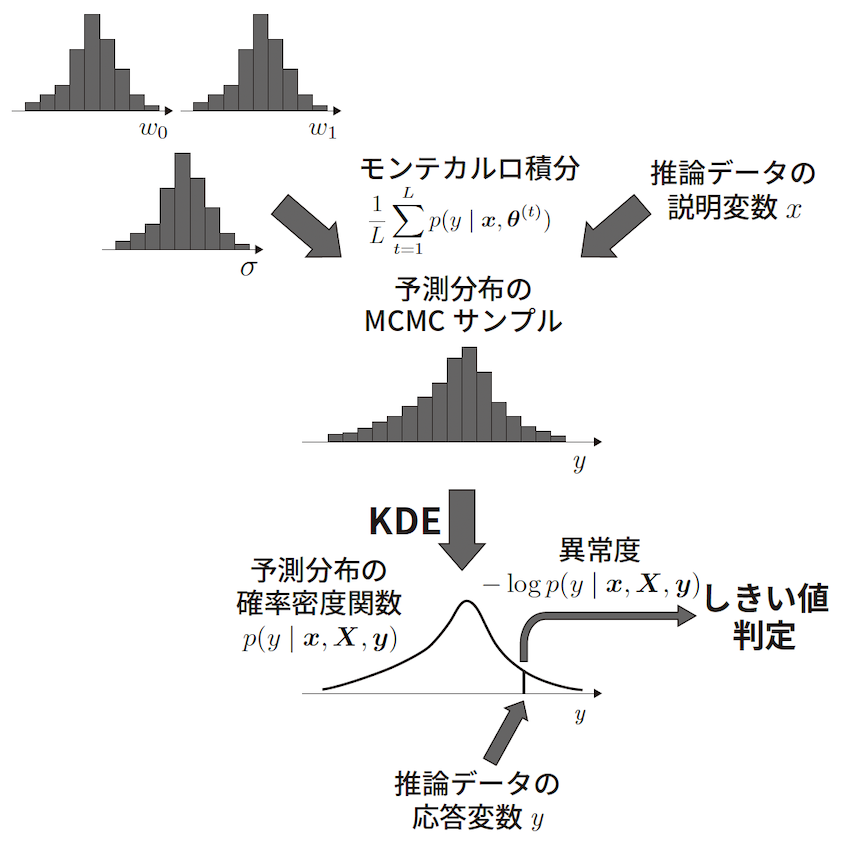

まずは以下のように、学習時に保存したMCMC サンプルとOneHotEncoderを読み込みます。

In [ ]:
# コード8.9 学習時に保存したMCMC サンプルとone-hot encoding 用モデルの読み込み
# MCMCサンプルを読み込み
filepath_mcmc = './8_4_2_mcmc_samples.nc'
posterior_mcmc = xr.load_dataset(filepath_mcmc)
# OneHotEncoderを読み込み
filepath = './8_4_2_onehot_encoder.pkl' # モデルの保存ファイル名
with open(filepath,'rb') as p: #ファイルを開く
    enc = pickle.load(p) # pickle形式ファイルからモデルを読み込み

以下の実装で、先ほどの図のフローに基づき推論データに対する異常判定を実施します。

In [ ]:
A_TH=7.9838719152911315 # 学習時に求めた異常度のしきい値

###### 推論データの読み込みと前処理（7章の最尤推定による多変数線形回帰モデルと同様）######
# CSVからPandas DataFrameにデータ読み込み
df_inference = pd.read_csv('./datasets/usedcar_dataset_inference.csv')
# カテゴリ変数'model_name'の数値化（one-hot encoding）
model_name_cat = enc.transform(df_inference[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_inference.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数（'year'）と応答変数（'price'）をNumpyのndarray化
X_inference = df_encoded[['year', 'odometer']+model_cat_names].to_numpy()
y_inference = df_encoded['price'].to_numpy()

###### 推論を実行######
seed=42 # 乱数シードを指定（結果の再現性を担保）
# 平均パラメータmuの事後分布のMCMCサンプルを計算
X_inference_xr = xr.DataArray(X_inference, dims=["record", "w_dim_0"])
mu_posterior = posterior_mcmc["w_0"]*xr.DataArray(np.ones(X_inference.shape[0]), dims=["record"]) \
    + xr.dot(posterior_mcmc["w"], X_inference_xr, dim=["w_dim_0"])
# 推論データから予測分布のMCMCサンプルと異常度を計算
sigma_posterior = posterior_mcmc["sigma"].to_numpy() # σの事後分布
anomaly_scores = []
for i, y in enumerate(y_inference): # データごとに予測分布を計算
    mu_posterior_i = mu_posterior[:, :, i].to_numpy()
    # 予測分布のMCMCサンプルを計算
    posterior_predictive = stats.norm.rvs(
        loc=mu_posterior_i,
        scale=sigma_posterior,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # KDEで予測分布の確率密度関数を計算
    kernel = stats.gaussian_kde(posterior_predictive.ravel())
    # KDE結果とyの値から確率密度と異常度を計算
    pdf = kernel(y)[0] # 確率密度
    anomaly_scores.append(-np.log(pdf)) # 異常度
# しきい値により異常の有無を判定
pred = np.where(np.array(anomaly_scores) > A_TH, 'anomaly', 'normal')
# 推論結果を表示
print(pred)

推論結果の決定境界（異常と正常の判定の境界）を可視化してみます。最尤推定による線形回帰の実装と同様、個々のグラフは横軸に説明変数`year`、縦軸に応答変数`price`をとっており、横方向には車種（`model_name`）、縦方向には経過年数（`year`= 1, 5, 10）を変えたときのグラフを並べています。

In [ ]:
# 推論結果の決定境界を可視化
# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

###### 正常と異常の範囲を色分け ######
# 削除したカテゴリの列を表示用に追加する
droped_model_name = enc.categories_[0][0]
df_X_inference = df_encoded[['year', 'odometer']+model_cat_names]
X_inference_with_dropped = df_X_inference.copy()
X_inference_with_dropped[f'model_name_{droped_model_name}'] = (df_inference['model_name'] == droped_model_name).astype('float64')
# 車種ごとに図を分ける
for model_idx, model_cat_name in enumerate(model_cat_names+[f'model_name_{droped_model_name}']):
    df_inference_model = df_inference[X_inference_with_dropped[model_cat_name] == 1]
    # yearごとに図を分ける
    for year_idx, year in enumerate([1, 5, 10]):
        df_inference_year = df_inference_model[df_inference_model['year'] == year]
        ###### 確率密度関数を描画 ######
        # (x,y)格子点を作成
        x_min, x_max = np.min(df_X_inference['odometer']), np.max(df_X_inference['odometer'])
        y_min, y_max = np.min(y_inference), np.max(y_inference)
        x_grid = np.linspace(x_min-1, x_max+2, num=100)
        y_grid = np.linspace(y_min-50, y_max+50, num=200)
        X, Y = np.meshgrid(x_grid, y_grid)
        # 格子点の説明変数データに車種とyearを追加
        X_grid = x_grid.reshape(-1, 1)
        for i_model in range(len(model_cat_names)):
            if i_model == model_idx:
                X_grid = np.insert(X_grid, i_model+1, 1, axis=1)
            else:
                X_grid = np.insert(X_grid, i_model+1, 0, axis=1)
        X_grid = np.insert(X_grid, 0, year, axis=1)  # year
        # 平均パラメータmuの事後分布のMCMCサンプルを計算
        X_grid_xr = xr.DataArray(X_grid, dims=["x_odometer", "w_dim_0"])
        mu_posterior = posterior_mcmc["w_0"] * xr.DataArray(np.ones(X_grid.shape[0]), dims=["x_odometer"]) \
            + xr.dot(posterior_mcmc["w"], X_grid_xr, dim=["w_dim_0"])
        sigma_posterior = posterior_mcmc["sigma"].to_numpy()  # σの事後分布
        # xの値ごとに予測分布を計算
        pdf_all_grid = []
        for x_idx, x_i in enumerate(x_grid):
            mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
            # 予測分布のMCMCサンプルを計算
            posterior_predictive = stats.norm.rvs(
                loc=mu_posterior_i,
                scale=sigma_posterior,
                size=mu_posterior_i.shape,
                random_state=seed
            )
            # KDEで予測分布の確率密度関数を計算
            kernel = stats.gaussian_kde(posterior_predictive.ravel())
            pdf_i = kernel(y_grid)  # 確率密度
            # データを保持
            pdf_all_grid.append(pdf_i)
        pdf_grid_pivot = np.array(pdf_all_grid).T
        # 異常度を算出（ゼロ割の警告が出るが処理自体は行われる）
        anomaly_scores_pivot = -np.log(pdf_grid_pivot)
        # しきい値判定
        pred_pivot = np.where(anomaly_scores_pivot > A_TH, 0, 1)
        # 正常と異常の境界をプロット
        axes[year_idx][model_idx].contourf(X, Y, pred_pivot, levels=1,
                            cmap=cm.gray, alpha=0.5)

        ###### 各データを散布図としてプロット ######
        sns.scatterplot(data=df_inference_year, x='odometer', y='price',
                        hue='label', palette=['#999999', '#111111'], ax=axes[year_idx][model_idx])
        # 図タイトルと凡例を追加
        axes[year_idx][model_idx].set_title(f'{model_cat_name.replace("name_", "name=")},  year={year}', fontsize=14)
        axes[year_idx][model_idx].legend()
# グラフを表示
plt.tight_layout()
plt.show()

7章の最尤推定を使用した線形回帰による実装例とほぼ同じ決定境界が引かれていることがわかります。今回はデータ数が比較的多い上に、学習データの四分位点からしきい値を求めているため、最尤推定とベイズ推定に⼤きな差がなかったと推測されます

## 別解：応答変数$y$に直接しきい値を設ける実装

学習データ数が少ない（数百個以下）場合を想定し、応答変数$y$に直接しきい値を設ける実装法も紹介します。
学習フローはここまで紹介した異常度にしきい値を設ける方法と同じですが、推論フローを以下のように変更します。

- 異常度にしきい値を設ける方法と同様の手順で、予測分布のMCMCサンプルを得る
- 予測分布のMCMCサンプルについて、ターゲットとする誤報率に対応する上下の分位点を計算し、それを応答変数$y$のしきい値とする
- 推論データの応答変数$y$が、このしきい値の範囲外にあれば異常あり、範囲内にあれば異常なしと判定する

In [ ]:
# コード8.11 応答変数y に直接しきい値を設ける方法による異常判定
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）

###### 推論データの読み込みと前処理（7章の最尤推定による多変数線形回帰モデルと同様）######
# CSVからPandas DataFrameにデータ読み込み
df_inference = pd.read_csv('./datasets/usedcar_dataset_inference.csv')
# カテゴリ変数'model_name'の数値化（one-hot encoding）
model_name_cat = enc.transform(df_inference[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_inference.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数（'year'）と応答変数（'price'）をNumpyのndarray化
X_inference = df_encoded[['year', 'odometer']+model_cat_names].to_numpy()
y_inference = df_encoded['price'].to_numpy()

###### 推論を実行######
seed=42 # 乱数シードを指定（結果の再現性を担保）
# 平均パラメータmuの事後分布のMCMCサンプルを計算
X_inference_xr = xr.DataArray(X_inference, dims=["record", "w_dim_0"])
mu_posterior = posterior_mcmc["w_0"]*xr.DataArray(np.ones(X_inference.shape[0]), dims=["record"]) \
    + xr.dot(posterior_mcmc["w"], X_inference_xr, dim=["w_dim_0"])
# 推論データから予測分布のMCMCサンプルを計算し、しきい値判定
sigma_posterior = posterior_mcmc["sigma"].to_numpy() # σの事後分布
predictions = []
for i, y in enumerate(y_inference): # データごとに予測分布を計算
    mu_posterior_i = mu_posterior[:, :, i].to_numpy()
    # 予測分布のMCMCサンプルを計算
    posterior_predictive = stats.norm.rvs(
        loc=mu_posterior_i,
        scale=sigma_posterior,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # 下側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
    th_lower = np.quantile(posterior_predictive, TARGET_FP_RATE/2)
    # 上側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
    th_upper = np.quantile(posterior_predictive, 1 - TARGET_FP_RATE/2)
    # しきい値判定
    pred = np.where((y < th_lower) | (y > th_upper), 'anomaly', 'normal')
    predictions.append(str(pred))
# 推論結果を表示
print(predictions)

推論結果の決定境界（異常と正常の判定の境界）を可視化してみます。

In [ ]:
# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

###### 正常と異常の範囲を色分け ######
# 削除したカテゴリの列を表示用に追加する
droped_model_name = enc.categories_[0][0]
df_X_inference = df_encoded[['year', 'odometer']+model_cat_names]
X_inference_with_dropped = df_X_inference.copy()
X_inference_with_dropped[f'model_name_{droped_model_name}'] = (df_inference['model_name'] == droped_model_name).astype('float64')
# 車種ごとに図を分ける
for model_idx, model_cat_name in enumerate(model_cat_names+[f'model_name_{droped_model_name}']):
    df_inference_model = df_inference[X_inference_with_dropped[model_cat_name] == 1]
    # yearごとに図を分ける
    for year_idx, year in enumerate([1, 5, 10]):
        df_inference_year = df_inference_model[df_inference_model['year'] == year]
        ###### 確率密度関数を描画 ######
        # (x,y)格子点を作成
        x_min, x_max = np.min(df_X_inference['odometer']), np.max(df_X_inference['odometer'])
        y_min, y_max = np.min(y_inference), np.max(y_inference)
        x_grid = np.linspace(x_min-1, x_max+2, num=100)
        y_grid = np.linspace(y_min-50, y_max+50, num=200)
        X, Y = np.meshgrid(x_grid, y_grid)
        # 格子点の説明変数データに車種とyearを追加
        X_grid = x_grid.reshape(-1, 1)
        for i_model in range(len(model_cat_names)):
            if i_model == model_idx:
                X_grid = np.insert(X_grid, i_model+1, 1, axis=1)
            else:
                X_grid = np.insert(X_grid, i_model+1, 0, axis=1)
        X_grid = np.insert(X_grid, 0, year, axis=1)  # year
        # 平均パラメータmuの事後分布のMCMCサンプルを計算
        X_grid_xr = xr.DataArray(X_grid, dims=["x_odometer", "w_dim_0"])
        mu_posterior = posterior_mcmc["w_0"] * xr.DataArray(np.ones(X_grid.shape[0]), dims=["x_odometer"]) \
            + xr.dot(posterior_mcmc["w"], X_grid_xr, dim=["w_dim_0"])
        sigma_posterior = posterior_mcmc["sigma"].to_numpy()  # σの事後分布
        # xの値ごとに予測分布を計算
        pdf_all_grid = []
        pred_all_grid = []
        for x_idx, x_i in enumerate(x_grid):
            mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
            # 予測分布のMCMCサンプルを計算
            posterior_predictive = stats.norm.rvs(
                loc=mu_posterior_i,
                scale=sigma_posterior,
                size=mu_posterior_i.shape,
                random_state=seed
            )
            # 下側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
            th_lower = np.quantile(posterior_predictive, TARGET_FP_RATE/2)
            # 上側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
            th_upper = np.quantile(posterior_predictive, 1 - TARGET_FP_RATE/2)
            # しきい値判定
            pred = np.where((y_grid < th_lower) | (y_grid > th_upper), 0, 1)
            # データを保持
            pred_all_grid.append(pred)
        pred_all_pivot = np.array(pred_all_grid).T
        # 正常と異常の境界をプロット
        axes[year_idx][model_idx].contourf(X, Y, pred_all_pivot, levels=1,
                            cmap=cm.gray, alpha=0.5)

        ###### 各データを散布図としてプロット ######
        sns.scatterplot(data=df_inference_year, x='odometer', y='price',
                        hue='label', palette=['#999999', '#111111'], ax=axes[year_idx][model_idx])
        # 図タイトルと凡例を追加
        axes[year_idx][model_idx].set_title(f'{model_cat_name.replace("name_", "name=")},  year={year}', fontsize=14)
        axes[year_idx][model_idx].legend()
# グラフを表示
plt.tight_layout()
plt.show()

先ほどの異常度にしきい値を設ける方法と、ほぼ同様の決定境界が引かれています。今回はデータ数が比較的多いため、両方法に⼤きな差が出なかったと推定されますが、少数データでも安定してしきい値を設定できるという点で、この方法は実用的です。